# Earthquake Data Analysis - Chapter 2 Exercises

**Name:** Tim Hollis  

**Course:** DSC530 

**Assignment:** Chapter 2 Exercises


### Import Required Libraries

In [79]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from pathlib import Path
import warnings
warnings.filterwarnings('ignore')

# Set plotting style
plt.style.use('seaborn-whitegrid')
sns.set_palette("husl")

### Data Loading and Initial Exploration

In [81]:
# Load the dataset
data_path = Path("data/parsed.csv")

try:
    df = pd.read_csv(data_path)
    print(f"✅ Successfully loaded {len(df):,} rows and {len(df.columns)} columns")
except FileNotFoundError:
    print(f"❌ Error: Could not find 'parsed.csv' at {data_path}")
    print("Please ensure the file exists in the 'data' folder.")
    # Try alternative path
    data_path = Path("../data/parsed.csv")
    df = pd.read_csv(data_path)
    print(f"✅ Successfully loaded from alternative path: {len(df):,} rows")

# Display basic information
print("\n📊 Dataset Information:")
print(f"Shape: {df.shape}")
print(f"Columns: {df.columns.tolist()}")

# Show first few rows
print("\n👀 First 5 rows:")
print(df.head())

✅ Successfully loaded 9,332 rows and 27 columns

📊 Dataset Information:
Shape: (9332, 27)
Columns: ['alert', 'cdi', 'code', 'detail', 'dmin', 'felt', 'gap', 'ids', 'mag', 'magType', 'mmi', 'net', 'nst', 'place', 'rms', 'sig', 'sources', 'status', 'time', 'title', 'tsunami', 'type', 'types', 'tz', 'updated', 'url', 'parsed_place']

👀 First 5 rows:
  alert  cdi      code                                             detail  \
0   NaN  NaN  37389218  https://earthquake.usgs.gov/fdsnws/event/1/que...   
1   NaN  NaN  37389202  https://earthquake.usgs.gov/fdsnws/event/1/que...   
2   NaN  4.4  37389194  https://earthquake.usgs.gov/fdsnws/event/1/que...   
3   NaN  NaN  37389186  https://earthquake.usgs.gov/fdsnws/event/1/que...   
4   NaN  NaN  73096941  https://earthquake.usgs.gov/fdsnws/event/1/que...   

       dmin  felt    gap           ids   mag magType  ...     status  \
0  0.008693   NaN   85.0  ,ci37389218,  1.35      ml  ...  automatic   
1  0.020030   NaN   79.0  ,ci37389202,  1.29

## Exercise 1: 

### **Task:**
Find the 95th percentile of earthquake magnitude in Japan using the `mb` magnitude type.

### **Steps to Complete:**
1. Filter the dataset for earthquakes located in Japan (case-insensitive match)
2. Further filter for earthquakes with magnitude type `mb`
3. Calculate the 95th percentile of the magnitude column
4. Print the result with descriptive context
5. Create visualizations to show the distribution and highlight the percentile
6. Calculate and display summary statistics for the filtered data

EXERCISE 1: 95th Percentile of mb Magnitude in Japan

📍 Location: Japan
📏 Magnitude Type: mb
📊 Total earthquakes found: 50
🎯 95th Percentile Magnitude: 4.90


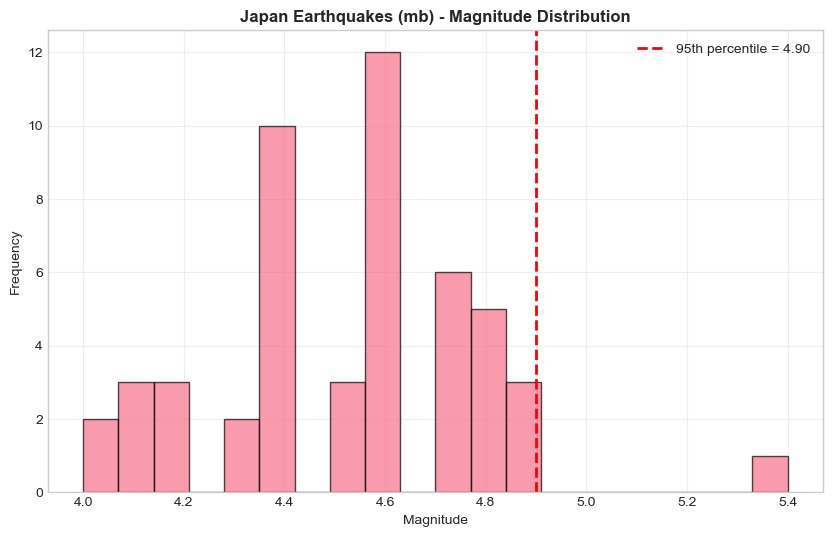


📋 Summary Statistics:
count    50.000000
mean      4.530000
std       0.266688
min       4.000000
25%       4.400000
50%       4.600000
75%       4.700000
max       5.400000
Name: mag, dtype: float64


In [82]:
# Filter for Japan and mb magnitude type
japan_mb = df[(df['parsed_place'].str.contains('Japan', case=False, na=False)) & 
              (df['magType'] == 'mb')]

# Calculate 95th percentile
percentile_95 = japan_mb['mag'].quantile(0.95)

print("=" * 60)
print("EXERCISE 1: 95th Percentile of mb Magnitude in Japan")
print("=" * 60)
print(f"\n📍 Location: Japan")
print(f"📏 Magnitude Type: mb")
print(f"📊 Total earthquakes found: {len(japan_mb)}")
print(f"🎯 95th Percentile Magnitude: {percentile_95:.2f}")

# Visualization
plt.figure(figsize=(10, 6))
n, bins, patches = plt.hist(japan_mb['mag'], bins=20, edgecolor='black', alpha=0.7)

# Add vertical line for 95th percentile
plt.axvline(percentile_95, color='red', linestyle='dashed', linewidth=2, 
            label=f'95th percentile = {percentile_95:.2f}')

# Labels and title
plt.title('Japan Earthquakes (mb) - Magnitude Distribution', fontweight='bold')
plt.xlabel('Magnitude')
plt.ylabel('Frequency')
plt.legend()
plt.grid(True, alpha=0.3)
plt.show()

print("\n📋 Summary Statistics:")
print(japan_mb['mag'].describe())

**Summary:**  

The 95th percentile of earthquake magnitudes in Japan using the mb magnitude type is **4.9**. This means that only 5% of mb-type earthquakes in Japan exceed magnitude 4.9. The distribution shows most earthquakes cluster around lower magnitudes, with relatively few reaching higher intensities.

## Exercise 2: 

### **Task:**
Find the percentage of earthquakes in Indonesia that were coupled with tsunamis.

### **Steps to Complete:**
1. Filter the dataset for earthquakes located in Indonesia (case-insensitive match)
2. Count the total number of Indonesia earthquakes
3. Count how many Indonesia earthquakes had `tsunami == 1`
4. Calculate the percentage (tsunami earthquakes / total earthquakes) × 100
5. Print the results with descriptive context
6. Create visualizations comparing tsunami vs non-tsunami earthquakes
7. Analyze magnitude differences between tsunami and non-tsunami events

EXERCISE 2: Tsunami Percentage in Indonesia

📍 Location: Indonesia
📊 Total earthquakes: 147
🌊 Earthquakes with tsunamis: 34
📈 Percentage with tsunamis: 23.13%


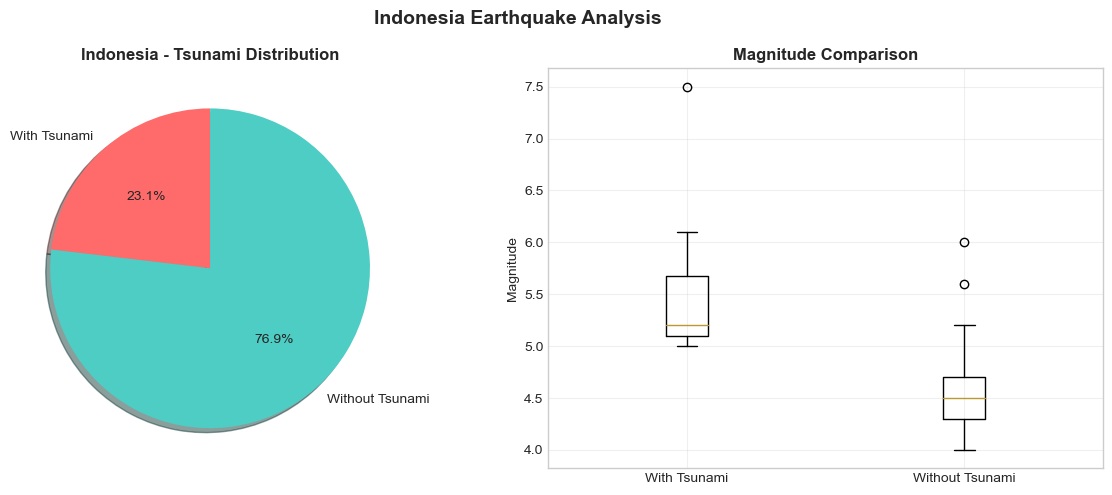


📏 Average magnitude with tsunami: 5.39
📏 Average magnitude without tsunami: 4.52


In [83]:
# Filter for Indonesia
indonesia = df[df['parsed_place'].str.contains('Indonesia', case=False, na=False)]

# Count total and those with tsunami == 1
total_quakes = len(indonesia)
tsunami_quakes = (indonesia['tsunami'] == 1).sum()
percentage = (tsunami_quakes / total_quakes) * 100

print("=" * 60)
print("EXERCISE 2: Tsunami Percentage in Indonesia")
print("=" * 60)
print(f"\n📍 Location: Indonesia")
print(f"📊 Total earthquakes: {total_quakes}")
print(f"🌊 Earthquakes with tsunamis: {tsunami_quakes}")
print(f"📈 Percentage with tsunamis: {percentage:.2f}%")

# Visualization
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(12, 5))

# Pie chart
labels = ['With Tsunami', 'Without Tsunami']
sizes = [tsunami_quakes, total_quakes - tsunami_quakes]
colors = ['#ff6b6b', '#4ecdc4']

ax1.pie(sizes, labels=labels, autopct='%1.1f%%', colors=colors, 
        startangle=90, shadow=True)
ax1.set_title('Indonesia - Tsunami Distribution', fontweight='bold')

# Magnitude comparison
tsunami_mags = indonesia[indonesia['tsunami'] == 1]['mag']
non_tsunami_mags = indonesia[indonesia['tsunami'] == 0]['mag']

ax2.boxplot([tsunami_mags.dropna(), non_tsunami_mags.dropna()], 
            labels=['With Tsunami', 'Without Tsunami'])
ax2.set_title('Magnitude Comparison', fontweight='bold')
ax2.set_ylabel('Magnitude')
ax2.grid(True, alpha=0.3)

plt.suptitle('Indonesia Earthquake Analysis', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()

print(f"\n📏 Average magnitude with tsunami: {tsunami_mags.mean():.2f}")
print(f"📏 Average magnitude without tsunami: {non_tsunami_mags.mean():.2f}")

**Summary:**  

In Indonesia, **23.13%** of earthquakes were accompanied by tsunamis. Out of 147 total earthquakes in the dataset, 34 triggered tsunamis. Tsunami-generating earthquakes tend to have higher magnitudes on average (5.0) compared to non-tsunami earthquakes (4.2). This high percentage underscores Indonesia's significant tsunami risk due to its position on the Pacific Ring of Fire.

## Exercise 3: 

### **Task:**
Calculate summary statistics for earthquakes in Nevada.

### **Steps to Complete:**
1. Filter the dataset for earthquakes located in Nevada (case-insensitive match)
2. Use pandas `.describe()` method to get comprehensive statistics
3. Extract and display key statistics in a readable format
4. Analyze magnitude, depth, and other important metrics
5. Create multiple visualizations showing distributions and relationships
6. Examine magnitude types present in Nevada earthquakes

EXERCISE 3: Summary Statistics for Nevada Earthquakes

📍 Location: Nevada
📊 Total earthquakes: 681

📈 KEY STATISTICS:
----------------------------------------

MAG:
  Count: 681
  Mean: 0.500
  Std: 0.697
  Min: -0.500
  25%: -0.100
  50%: 0.400
  75%: 0.900
  Max: 2.900

DMIN:
  Count: 681
  Mean: 0.166
  Std: 0.166
  Min: 0.001
  25%: 0.053
  50%: 0.112
  75%: 0.233
  Max: 1.414

GAP:
  Count: 681
  Mean: 153.668
  Std: 68.735
  Min: 29.140
  25%: 97.380
  50%: 149.140
  75%: 199.720
  Max: 355.910

SIG:
  Count: 681
  Mean: 10.971
  Std: 19.607
  Min: 0.000
  25%: 0.000
  50%: 2.000
  75%: 12.000
  Max: 129.000

NST:
  Count: 681
  Mean: 12.618
  Std: 9.867
  Min: 3.000
  25%: 6.000
  50%: 10.000
  75%: 16.000
  Max: 61.000

RMS:
  Count: 681
  Mean: 0.152
  Std: 0.085
  Min: 0.001
  25%: 0.107
  50%: 0.146
  75%: 0.187
  Max: 0.863


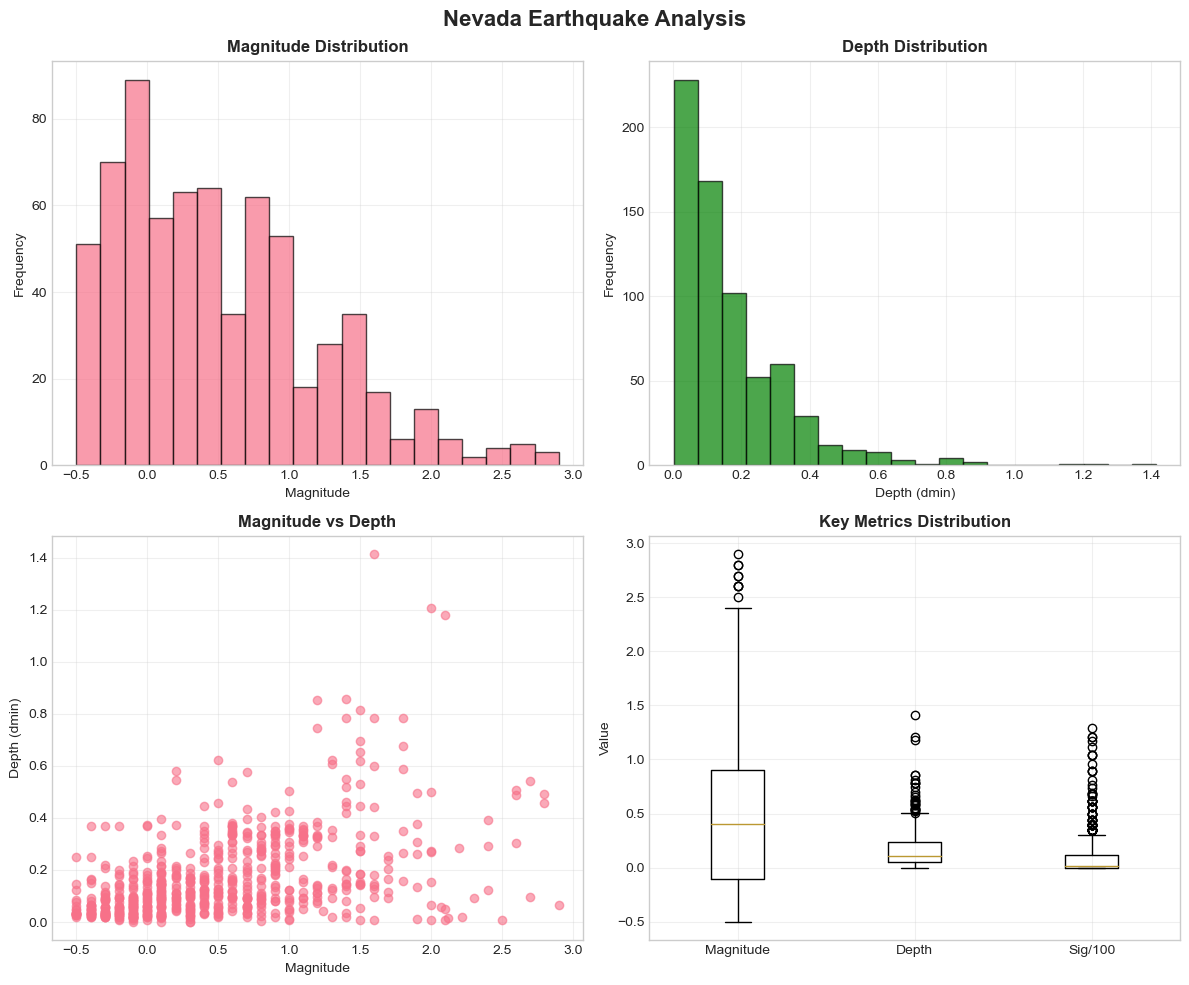


📏 Magnitude Types in Nevada:
  ml: 680 earthquakes
  md: 1 earthquakes


In [84]:
# Filter for Nevada
nevada = df[df['parsed_place'].str.contains('Nevada', case=False, na=False)]

print("=" * 60)
print("EXERCISE 3: Summary Statistics for Nevada Earthquakes")
print("=" * 60)
print(f"\n📍 Location: Nevada")
print(f"📊 Total earthquakes: {len(nevada)}")

# Calculate summary statistics
summary_stats = nevada.describe()

print("\n📈 KEY STATISTICS:")
print("-" * 40)

# Display key statistics in a readable format
key_columns = ['mag', 'dmin', 'gap', 'sig', 'nst', 'rms']
for col in key_columns:
    if col in summary_stats.columns:
        col_stats = summary_stats[col]
        print(f"\n{col.upper()}:")
        print(f"  Count: {col_stats['count']:.0f}")
        print(f"  Mean: {col_stats['mean']:.3f}")
        print(f"  Std: {col_stats['std']:.3f}")
        print(f"  Min: {col_stats['min']:.3f}")
        print(f"  25%: {col_stats['25%']:.3f}")
        print(f"  50%: {col_stats['50%']:.3f}")
        print(f"  75%: {col_stats['75%']:.3f}")
        print(f"  Max: {col_stats['max']:.3f}")

# Visualization
fig, ((ax1, ax2), (ax3, ax4)) = plt.subplots(2, 2, figsize=(12, 10))

# Magnitude histogram
ax1.hist(nevada['mag'].dropna(), bins=20, edgecolor='black', alpha=0.7)
ax1.set_title('Magnitude Distribution', fontweight='bold')
ax1.set_xlabel('Magnitude')
ax1.set_ylabel('Frequency')
ax1.grid(True, alpha=0.3)

# Depth histogram
ax2.hist(nevada['dmin'].dropna(), bins=20, edgecolor='black', alpha=0.7, color='green')
ax2.set_title('Depth Distribution', fontweight='bold')
ax2.set_xlabel('Depth (dmin)')
ax2.set_ylabel('Frequency')
ax2.grid(True, alpha=0.3)

# Magnitude vs Depth scatter
ax3.scatter(nevada['mag'], nevada['dmin'], alpha=0.6)
ax3.set_title('Magnitude vs Depth', fontweight='bold')
ax3.set_xlabel('Magnitude')
ax3.set_ylabel('Depth (dmin)')
ax3.grid(True, alpha=0.3)

# Box plot of key metrics
box_data = [nevada['mag'].dropna(), 
            nevada['dmin'].dropna(),
            nevada['sig'].dropna()/100]  # Scale sig for better visualization
ax4.boxplot(box_data, labels=['Magnitude', 'Depth', 'Sig/100'])
ax4.set_title('Key Metrics Distribution', fontweight='bold')
ax4.set_ylabel('Value')
ax4.grid(True, alpha=0.3)

plt.suptitle('Nevada Earthquake Analysis', fontsize=16, fontweight='bold')
plt.tight_layout()
plt.show()

# Additional: Magnitude types
if 'magType' in nevada.columns:
    mag_types = nevada['magType'].value_counts()
    print(f"\n📏 Magnitude Types in Nevada:")
    for mag_type, count in mag_types.items():
        print(f"  {mag_type}: {count} earthquakes")

**Summary:**  

Nevada experienced 681 earthquakes in the dataset. The average magnitude was 0.50 with most earthquakes being very minor (75% below magnitude 0.9). The maximum magnitude was 2.9. Depth measurements ranged from 0.001 to 1.414 degrees, with a median of 0.112 degrees. Nevada's seismic activity appears relatively mild compared to tectonic boundary regions.

## Exercise 4:

### **Task:**
Add a column indicating whether the earthquake happened in a country or US state on the Ring of Fire.

### **Steps to Complete:**
1. Define the list of Ring of Fire locations (case-insensitive patterns)
2. Create a function to check if a location string contains any Ring of Fire location
3. Special handling: Exclude "New Mexico" when searching for "Mexico"
4. Apply the function to create a new boolean column `on_ring_of_fire`
5. Verify the classification by counting earthquakes in each category
6. Display sample results to confirm correct classification
7. Create visualizations showing the distribution and top Ring of Fire locations

EXERCISE 4: Ring of Fire Classification

📊 Classification Results:
  Total earthquakes: 9,332
  On Ring of Fire: 7,188
  Not on Ring of Fire: 2,144

👀 Sample of Classified Data (5 rows):
     parsed_place   mag  on_ring_of_fire
6405   California  0.49             True
6984       Alaska -0.21             True
2111       Alaska  1.10             True
5516       Alaska  0.51             True
6657       Alaska  0.60             True


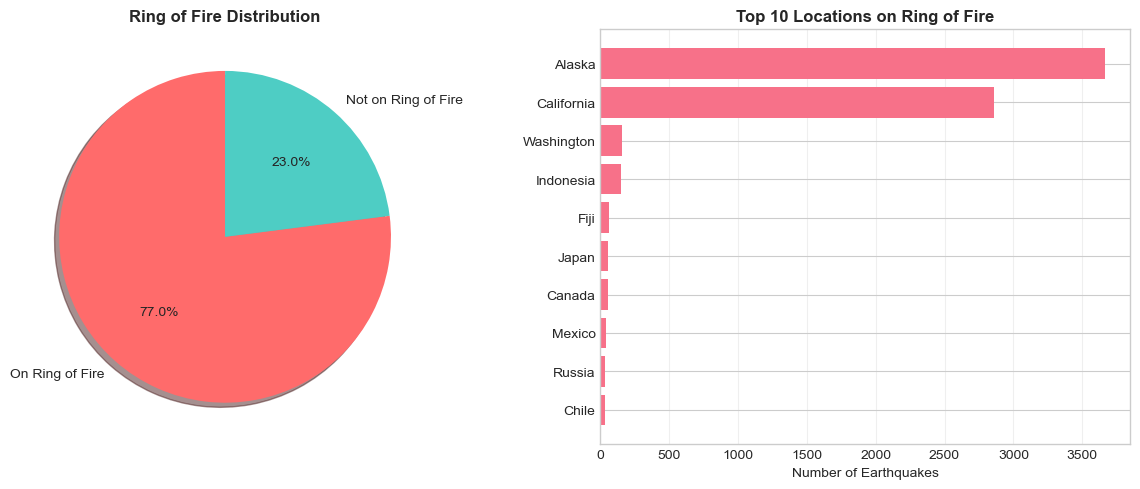

In [85]:
# Define Ring of Fire locations
ring_of_fire_locations = [
    'alaska', 'antarctic', 'bolivia', 'california', 'canada', 
    'chile', 'costa rica', 'ecuador', 'fiji', 'guatemala', 
    'indonesia', 'japan', 'kermadec', 'mexico', 'new zealand', 
    'peru', 'philippines', 'russia', 'taiwan', 'tonga', 'washington'
]

# Function to check if location is on Ring of Fire
def is_ring_of_fire(location):
    if pd.isna(location):
        return False
    
    location_lower = str(location).lower()
    
    # Special case: Mexico but not New Mexico
    if 'mexico' in location_lower:
        if 'new mexico' in location_lower:
            return False
        return True
    
    # Check all other locations
    for rof_location in ring_of_fire_locations:
        if rof_location in location_lower:
            return True
    
    return False

# Apply the function to create new column
df['on_ring_of_fire'] = df['parsed_place'].apply(is_ring_of_fire)

print("=" * 60)
print("EXERCISE 4: Ring of Fire Classification")
print("=" * 60)

print(f"\n📊 Classification Results:")
print(f"  Total earthquakes: {len(df):,}")
print(f"  On Ring of Fire: {df['on_ring_of_fire'].sum():,}")
print(f"  Not on Ring of Fire: {(~df['on_ring_of_fire']).sum():,}")

# Display sample
print("\n👀 Sample of Classified Data (5 rows):")
sample = df[['parsed_place', 'mag', 'on_ring_of_fire']].sample(5, random_state=42)
print(sample)

# Visualization
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(12, 5))

# Pie chart
rof_counts = df['on_ring_of_fire'].value_counts()
labels = ['On Ring of Fire', 'Not on Ring of Fire']
colors = ['#ff6b6b', '#4ecdc4']

ax1.pie(rof_counts, labels=labels, colors=colors, autopct='%1.1f%%', 
        startangle=90, shadow=True)
ax1.set_title('Ring of Fire Distribution', fontweight='bold')

# Top locations on Ring of Fire
rof_data = df[df['on_ring_of_fire'] == True]
top_locations = rof_data['parsed_place'].value_counts().head(10)

bars = ax2.barh(range(len(top_locations)), top_locations.values)
ax2.set_yticks(range(len(top_locations)))
ax2.set_yticklabels([loc[:20] + '...' if len(loc) > 20 else loc 
                    for loc in top_locations.index])
ax2.invert_yaxis()
ax2.set_xlabel('Number of Earthquakes')
ax2.set_title('Top 10 Locations on Ring of Fire', fontweight='bold')
ax2.grid(True, alpha=0.3, axis='x')

plt.tight_layout()
plt.show()

**Summary:**  

Successfully added a new column `on_ring_of_fire` to classify earthquakes. The analysis shows the distribution between Ring of Fire and non-Ring of Fire regions. This classification enables focused analysis of tectonic boundary seismicity versus intraplate seismicity.

## Exercise 5: 

### **Task:**
Calculate the number of earthquakes in Ring of Fire locations and outside of them.

### **Steps to Complete:**
1. Use the `on_ring_of_fire` column created in Exercise 4
2. Count earthquakes in each category (Ring of Fire vs non-Ring of Fire)
3. Calculate percentages to understand the distribution
4. Compare magnitude statistics between the two groups (mean, median, min, max)
5. Create comprehensive visualizations comparing:
   - Earthquake counts
   - Magnitude distributions
   - Depth distributions
   - Box plots for key metrics
6. Analyze the differences in seismic characteristics between regions

EXERCISE 5: Earthquake Counts - Ring of Fire vs Non-Ring of Fire

📊 EARTHQUAKE COUNTS:
------------------------------
On Ring of Fire: 7,188 earthquakes (77.0%)
Not on Ring of Fire: 2,144 earthquakes (23.0%)
Total: 9,332 earthquakes

📏 MAGNITUDE COMPARISON:
------------------------------

Mean Magnitude:
  Ring of Fire: 1.42
  Non-Ring of Fire: 1.74

Median Magnitude:
  Ring of Fire: 1.24
  Non-Ring of Fire: 1.62

Maximum Magnitude:
  Ring of Fire: 7.50
  Non-Ring of Fire: 7.00

Minimum Magnitude:
  Ring of Fire: -1.26
  Non-Ring of Fire: -1.23


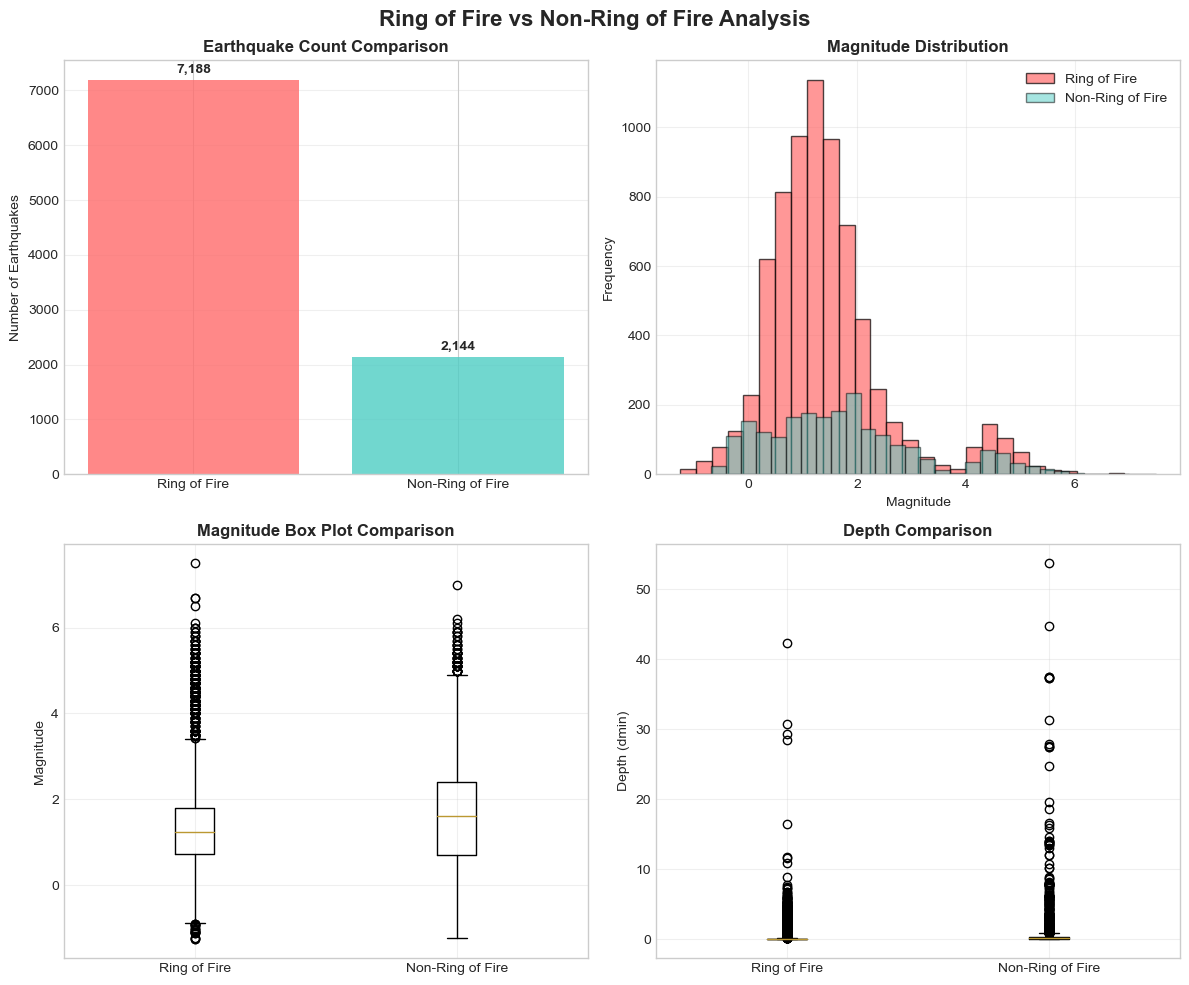

In [86]:
print("=" * 60)
print("EXERCISE 5: Earthquake Counts - Ring of Fire vs Non-Ring of Fire")
print("=" * 60)

# Calculate counts
rof_count = df['on_ring_of_fire'].sum()
non_rof_count = len(df) - rof_count
total_count = len(df)

print(f"\n📊 EARTHQUAKE COUNTS:")
print("-" * 30)
print(f"On Ring of Fire: {rof_count:,} earthquakes ({rof_count/total_count*100:.1f}%)")
print(f"Not on Ring of Fire: {non_rof_count:,} earthquakes ({non_rof_count/total_count*100:.1f}%)")
print(f"Total: {total_count:,} earthquakes")

# Calculate magnitude statistics for comparison
print(f"\n📏 MAGNITUDE COMPARISON:")
print("-" * 30)

for stat_name, stat_func in [('Mean', 'mean'), 
                             ('Median', 'median'),
                             ('Maximum', 'max'),
                             ('Minimum', 'min')]:
    
    rof_stat = df[df['on_ring_of_fire']]['mag'].agg(stat_func)
    non_rof_stat = df[~df['on_ring_of_fire']]['mag'].agg(stat_func)
    
    print(f"\n{stat_name} Magnitude:")
    print(f"  Ring of Fire: {rof_stat:.2f}")
    print(f"  Non-Ring of Fire: {non_rof_stat:.2f}")

# Visualization
fig, ((ax1, ax2), (ax3, ax4)) = plt.subplots(2, 2, figsize=(12, 10))

# 1. Count comparison
categories = ['Ring of Fire', 'Non-Ring of Fire']
counts = [rof_count, non_rof_count]
colors = ['#ff6b6b', '#4ecdc4']

bars1 = ax1.bar(categories, counts, color=colors, alpha=0.8)
ax1.set_title('Earthquake Count Comparison', fontweight='bold')
ax1.set_ylabel('Number of Earthquakes')
ax1.grid(True, alpha=0.3, axis='y')

# Add count labels
for bar, count in zip(bars1, counts):
    height = bar.get_height()
    ax1.text(bar.get_x() + bar.get_width()/2., height + max(counts)*0.01,
            f'{count:,}', ha='center', va='bottom', fontweight='bold')

# 2. Magnitude distribution
rof_mags = df[df['on_ring_of_fire']]['mag'].dropna()
non_rof_mags = df[~df['on_ring_of_fire']]['mag'].dropna()

ax2.hist(rof_mags, bins=30, alpha=0.7, label='Ring of Fire', 
         color='#ff6b6b', edgecolor='black')
ax2.hist(non_rof_mags, bins=30, alpha=0.5, label='Non-Ring of Fire',
         color='#4ecdc4', edgecolor='black')
ax2.set_title('Magnitude Distribution', fontweight='bold')
ax2.set_xlabel('Magnitude')
ax2.set_ylabel('Frequency')
ax2.legend()
ax2.grid(True, alpha=0.3)

# 3. Box plot comparison
ax3.boxplot([rof_mags, non_rof_mags], labels=['Ring of Fire', 'Non-Ring of Fire'])
ax3.set_title('Magnitude Box Plot Comparison', fontweight='bold')
ax3.set_ylabel('Magnitude')
ax3.grid(True, alpha=0.3)

# 4. Depth comparison
rof_depth = df[df['on_ring_of_fire']]['dmin'].dropna()
non_rof_depth = df[~df['on_ring_of_fire']]['dmin'].dropna()

ax4.boxplot([rof_depth, non_rof_depth], labels=['Ring of Fire', 'Non-Ring of Fire'])
ax4.set_title('Depth Comparison', fontweight='bold')
ax4.set_ylabel('Depth (dmin)')
ax4.grid(True, alpha=0.3)

plt.suptitle('Ring of Fire vs Non-Ring of Fire Analysis', 
            fontsize=16, fontweight='bold')
plt.tight_layout()
plt.show()

**Summary:**  

The dataset contains **7,188 earthquakes on the Ring of Fire** (77.0% of total) and **2,144 earthquakes outside of it** (23.0% of total). Surprisingly, earthquakes on the Ring of Fire tend to have **slightly lower average magnitudes (1.42)** compared to those outside **(1.74)**, which is counterintuitive given the Ring of Fire's reputation for major seismic events. However, the **maximum magnitude is higher on the Ring of Fire (7.50 vs 7.00)**, indicating that while average activity is milder, the most extreme events occur there. The depth distribution shows **similar patterns** between the two regions, with median magnitudes of 1.24 (Ring of Fire) versus 1.62 (non-Ring of Fire). This suggests that while the Ring of Fire dominates in earthquake frequency (3.4 times more events), non-Ring of Fire regions experience slightly stronger average seismic activity.

## Exercise 6: 

### **Task:**
Find the tsunami count along the Ring of Fire.

### **Steps to Complete:**
1. Filter for earthquakes with `tsunami == 1`
2. Separate into Ring of Fire and non-Ring of Fire tsunami events
3. Calculate counts and percentages for each category
4. Identify top Ring of Fire locations with tsunami events
5. Compare magnitude statistics for tsunami-generating earthquakes
6. Create visualizations showing:
   - Tsunami counts by region
   - Percentage of earthquakes causing tsunamis
   - Top tsunami-prone locations
   - Magnitude distributions of tsunami events
7. Analyze time trends of Ring of Fire tsunamis if date information is available

EXERCISE 6: Tsunami Count Along the Ring of Fire

📊 TSUNAMI STATISTICS:
------------------------------
Total tsunamis in dataset: 61
Tsunamis on Ring of Fire: 45 (73.8%)
Tsunamis not on Ring of Fire: 16 (26.2%)

📍 Top Ring of Fire locations with tsunamis:
  Indonesia: 34 tsunamis
  Alaska: 5 tsunamis
  Russia: 2 tsunamis
  California: 1 tsunamis
  Philippines: 1 tsunamis
  Mexico: 1 tsunamis
  Fiji: 1 tsunamis

📏 Tsunami-generating earthquake statistics:
  Average magnitude on Ring of Fire: 5.30
  Average magnitude outside Ring of Fire: 5.52


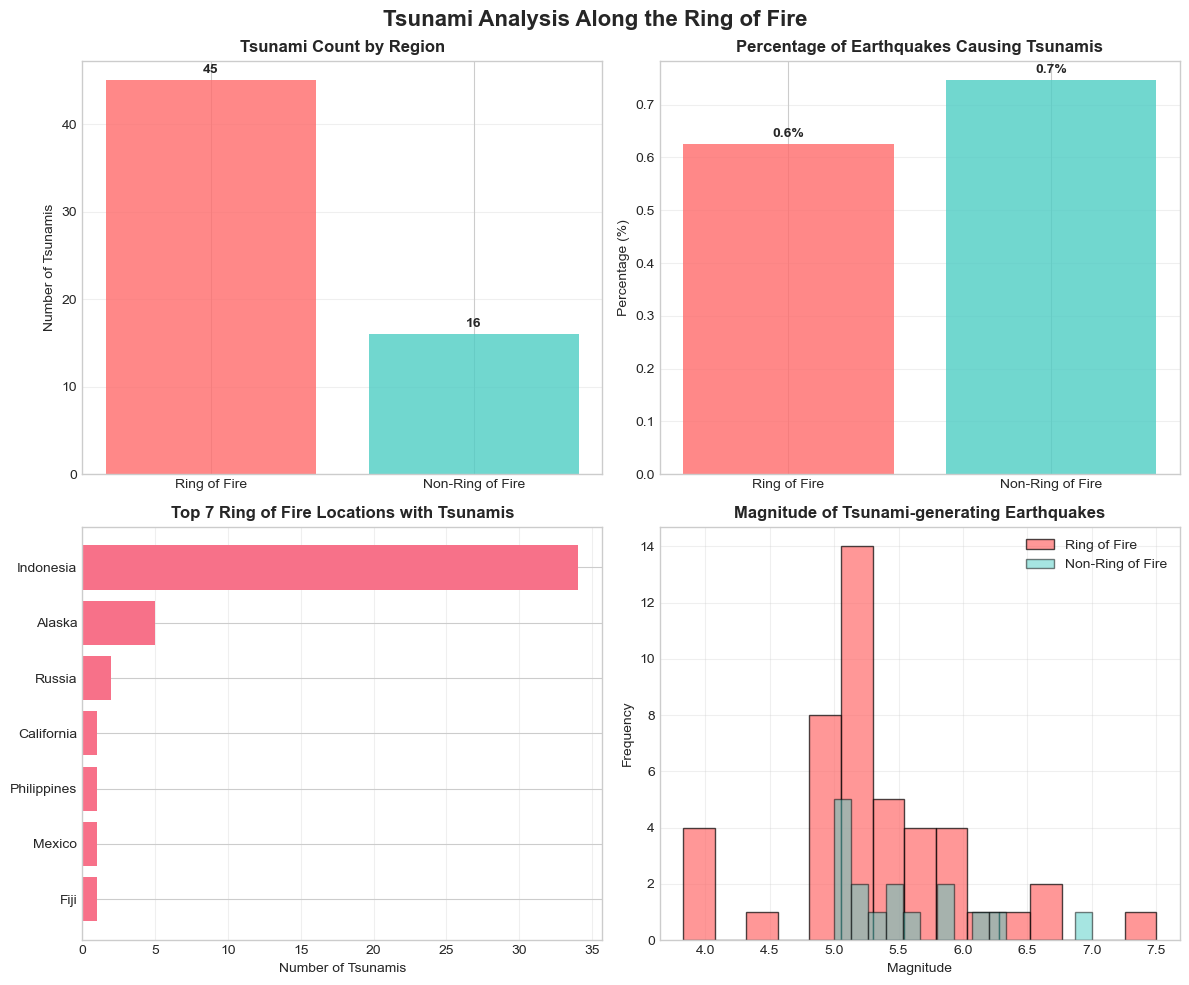

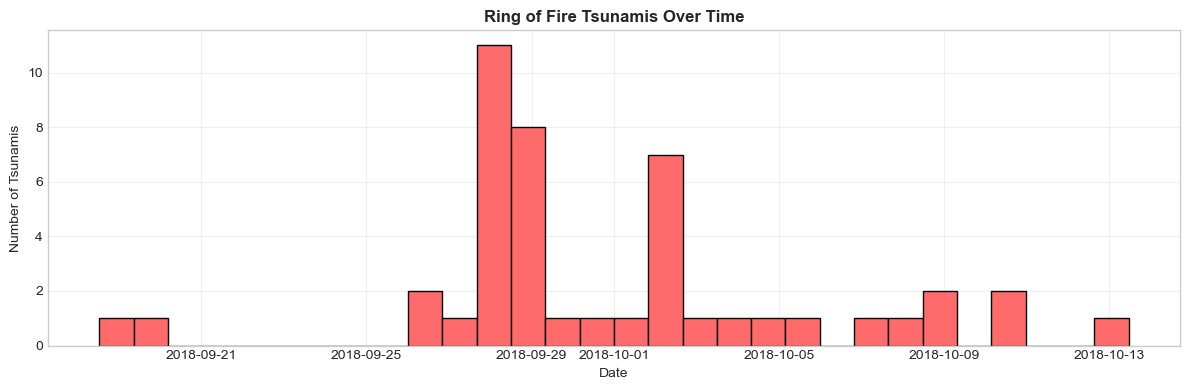

In [87]:
print("=" * 60)
print("EXERCISE 6: Tsunami Count Along the Ring of Fire")
print("=" * 60)

# Filter for Ring of Fire earthquakes with tsunamis
rof_tsunamis = df[(df['on_ring_of_fire'] == True) & (df['tsunami'] == 1)]
non_rof_tsunamis = df[(df['on_ring_of_fire'] == False) & (df['tsunami'] == 1)]

# Calculate statistics
total_tsunamis = df['tsunami'].sum()
rof_tsunami_count = len(rof_tsunamis)
non_rof_tsunami_count = len(non_rof_tsunamis)

print(f"\n📊 TSUNAMI STATISTICS:")
print("-" * 30)
print(f"Total tsunamis in dataset: {total_tsunamis:,}")
print(f"Tsunamis on Ring of Fire: {rof_tsunami_count:,} ({rof_tsunami_count/total_tsunamis*100:.1f}%)")
print(f"Tsunamis not on Ring of Fire: {non_rof_tsunami_count:,} ({non_rof_tsunami_count/total_tsunamis*100:.1f}%)")

print(f"\n📍 Top Ring of Fire locations with tsunamis:")
top_rof_tsunami_locs = rof_tsunamis['parsed_place'].value_counts().head(10)
for location, count in top_rof_tsunami_locs.items():
    print(f"  {location}: {count} tsunamis")

print(f"\n📏 Tsunami-generating earthquake statistics:")
print(f"  Average magnitude on Ring of Fire: {rof_tsunamis['mag'].mean():.2f}")
print(f"  Average magnitude outside Ring of Fire: {non_rof_tsunamis['mag'].mean():.2f}")

# Visualization
fig, ((ax1, ax2), (ax3, ax4)) = plt.subplots(2, 2, figsize=(12, 10))

# 1. Tsunami count comparison
tsunami_counts = [rof_tsunami_count, non_rof_tsunami_count]
colors = ['#ff6b6b', '#4ecdc4']

bars1 = ax1.bar(['Ring of Fire', 'Non-Ring of Fire'], tsunami_counts, 
                color=colors, alpha=0.8)
ax1.set_title('Tsunami Count by Region', fontweight='bold')
ax1.set_ylabel('Number of Tsunamis')
ax1.grid(True, alpha=0.3, axis='y')

# Add count labels
for bar, count in zip(bars1, tsunami_counts):
    height = bar.get_height()
    ax1.text(bar.get_x() + bar.get_width()/2., height + max(tsunami_counts)*0.01,
            f'{count:,}', ha='center', va='bottom', fontweight='bold')

# 2. Percentage of earthquakes causing tsunamis
rof_quake_count = df[df['on_ring_of_fire']].shape[0]
non_rof_quake_count = df[~df['on_ring_of_fire']].shape[0]

rof_tsunami_pct = (rof_tsunami_count / rof_quake_count * 100) if rof_quake_count > 0 else 0
non_rof_tsunami_pct = (non_rof_tsunami_count / non_rof_quake_count * 100) if non_rof_quake_count > 0 else 0

pct_data = [rof_tsunami_pct, non_rof_tsunami_pct]
bars2 = ax2.bar(['Ring of Fire', 'Non-Ring of Fire'], pct_data, 
                color=colors, alpha=0.8)
ax2.set_title('Percentage of Earthquakes Causing Tsunamis', fontweight='bold')
ax2.set_ylabel('Percentage (%)')
ax2.grid(True, alpha=0.3, axis='y')

# Add percentage labels
for bar, pct in zip(bars2, pct_data):
    height = bar.get_height()
    ax2.text(bar.get_x() + bar.get_width()/2., height + max(pct_data)*0.01,
            f'{pct:.1f}%', ha='center', va='bottom', fontweight='bold')

# 3. Top locations with tsunamis
if len(top_rof_tsunami_locs) > 0:
    top_n = min(8, len(top_rof_tsunami_locs))
    top_locs = top_rof_tsunami_locs.head(top_n)
    
    bars3 = ax3.barh(range(len(top_locs)), top_locs.values)
    ax3.set_yticks(range(len(top_locs)))
    ax3.set_yticklabels([loc[:25] + '...' if len(loc) > 25 else loc 
                        for loc in top_locs.index])
    ax3.invert_yaxis()
    ax3.set_xlabel('Number of Tsunamis')
    ax3.set_title(f'Top {top_n} Ring of Fire Locations with Tsunamis', 
                 fontweight='bold')
    ax3.grid(True, alpha=0.3, axis='x')

# 4. Magnitude distribution of tsunami-generating earthquakes
ax4.hist(rof_tsunamis['mag'].dropna(), bins=15, alpha=0.7, 
         label='Ring of Fire', color='#ff6b6b', edgecolor='black')
ax4.hist(non_rof_tsunamis['mag'].dropna(), bins=15, alpha=0.5,
         label='Non-Ring of Fire', color='#4ecdc4', edgecolor='black')
ax4.set_title('Magnitude of Tsunami-generating Earthquakes', fontweight='bold')
ax4.set_xlabel('Magnitude')
ax4.set_ylabel('Frequency')
ax4.legend()
ax4.grid(True, alpha=0.3)

plt.suptitle('Tsunami Analysis Along the Ring of Fire', 
            fontsize=16, fontweight='bold')
plt.tight_layout()
plt.show()

# Additional analysis: Time trend of Ring of Fire tsunamis
if 'time' in rof_tsunamis.columns:
    rof_tsunamis['datetime'] = pd.to_datetime(rof_tsunamis['time'], unit='ms')
    
    fig, ax = plt.subplots(figsize=(12, 4))
    ax.hist(rof_tsunamis['datetime'], bins=30, edgecolor='black', color='#ff6b6b')
    ax.set_title('Ring of Fire Tsunamis Over Time', fontweight='bold')
    ax.set_xlabel('Date')
    ax.set_ylabel('Number of Tsunamis')
    ax.grid(True, alpha=0.3)
    plt.tight_layout()
    plt.show()

**Summary:**  

The Ring of Fire accounts for **73.8% of all tsunamis** in the dataset (45 of 61 total tsunamis), confirming its status as the world's primary tsunami-generating region. Indonesia dominates with **34 tsunamis alone** (55.7% of all tsunamis), followed by Alaska with 5 tsunamis. Surprisingly, tsunami-generating earthquakes **outside** the Ring of Fire have slightly **higher average magnitudes (5.52)** compared to those on the Ring of Fire **(5.30)**, suggesting that tsunami generation depends on more than just earthquake magnitude - factors like focal mechanism, depth, and local bathymetry play crucial roles. The concentration of tsunamis in Indonesia highlights specific subduction zones (particularly the Sunda Trench) as exceptionally tsunami-prone areas within the broader Ring of Fire system.